In [11]:
# imports & path setup
from pathlib import Path
import sys
import pandas as pd

# Add project root (parent of "notebooks") to Python path
ROOT_DIR = Path("..").resolve()
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))


from src.utils_eda import (
    quick_overview,
    missing_report,
    split_num_cat,
    plot_numeric_distributions,
    show_categorical_value_counts,
)

DATA_DIR = Path("..") / "data" / "raw"
FILE_PATH = DATA_DIR / "credit_risk_dataset.csv"

In [12]:
# load data
df = pd.read_csv(FILE_PATH)
df.shape

(32581, 12)

In [13]:
print(df.head())
print(df.dtypes)

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [14]:
# call quick_overview
target_col = "loan_status"  # change this once you inspect actual column name
quick_overview(df, target_col=target_col)

Shape: (32581, 12)

Data types:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

First 5 rows:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4



Target 'loan_status' value counts:
loan_status
0    25473
1     7108
Name: count, dtype: int64


In [15]:
# missing values
missing_report(df, min_pct=0.0)

,missing_pct
loan_int_rate,9.56
person_emp_length,2.75
person_age,0.00
person_income,0.00
person_home_ownership,0.00
loan_intent,0.00
loan_grade,0.00
loan_amnt,0.00
loan_status,0.00
loan_percent_income,0.00


In [16]:
# numeric vs categorical
num_cols, cat_cols = split_num_cat(df, exclude=[target_col])
num_cols, cat_cols

(['cb_person_cred_hist_length',
  'loan_amnt',
  'loan_int_rate',
  'loan_percent_income',
  'person_age',
  'person_emp_length',
  'person_income'],
 ['cb_person_default_on_file',
  'loan_grade',
  'loan_intent',
  'person_home_ownership'])

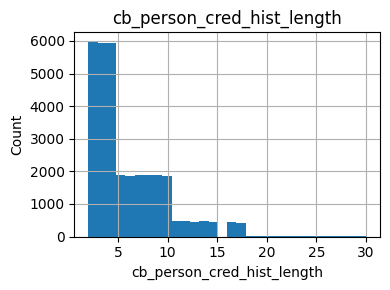

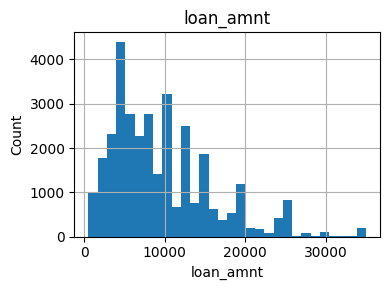

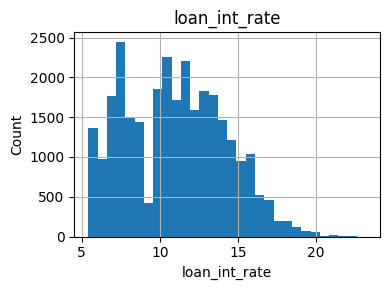

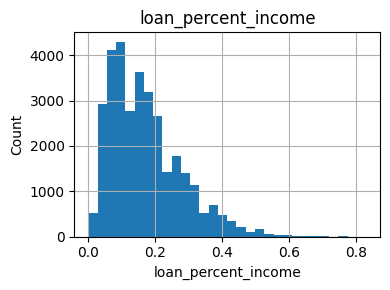

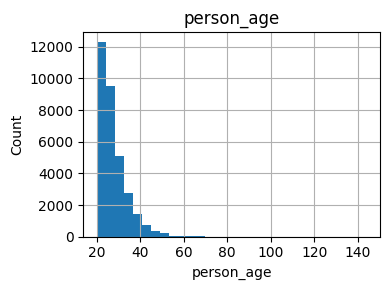

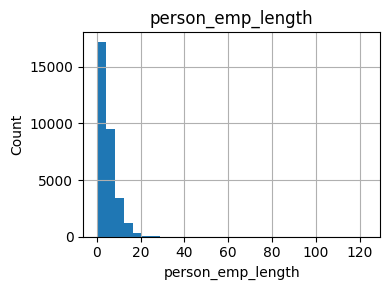


Column: cb_person_default_on_file (nunique=2)
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64

Column: loan_grade (nunique=7)
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

Column: loan_intent (nunique=6)
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

Column: person_home_ownership (nunique=4)
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64


In [17]:
### Basic distributions (maybe subset to a few columns)
plot_numeric_distributions(df, num_cols[:6])
show_categorical_value_counts(df, cat_cols)